## Mosquito Abundance Predictions

This code reads Aedes aegypti abundance data, together with mean temperature, precipitation, and relative humidity information in four neighborhoods in Puerto Rico. It then uses the weather data to create input files for an ANN trained on MoLS simulations. Finally, scaled ANN predictions are compared to the surveillance data. 

Import various libraries and read the mosquito data file. The information is stored in a dataframe called `mdata`.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys, os, joblib, importlib, glob, math
sys.path.append( os.path.abspath(os.path.join('..')) )
import utils.utils as gen_utils
from datetime import datetime, timedelta

from sklearn.preprocessing import MinMaxScaler



In [24]:
# Read data file
mdata=pd.read_csv('../data/Weather/Salinas_weather.csv')
sites=sorted(list(set(mdata.Site)))
print(sites)

['Arboleda', 'La_Margarita', 'Playa', 'Villodas']


## Create complete dataframes for each location

The `mdata` dataframe contains information about Arboleda. In addition, because of hurricane Maria, two weeks of weather and msoqutio data are missing. There is also one week, at the end of March 2016, where weather data is missing.

We therefore need to create an input file with weekly data interpolate the missing information over the two periods in question. Missing values are added through calls to `utils.add_missing_data` for the 2 weeks due to hurricane Maria, and to `utils.replace_nan_values` for the week of 3/2016.

The resulting files are called `Arboleda_data`.

In [25]:
importlib.reload(gen_utils)
# Set threshold (between 0 and 1) for zero rainfall
#Arboleda
Pdata = mdata[mdata["Site"].isin([sites[0]])]
Pdata.index=np.arange(Pdata.shape[0])
Pdata = Pdata.replace('#NULL!', math.nan)
for col in Pdata.columns[4:]:
    Pdata[col] = Pdata[col].astype(float)
Pdata.Datetime=pd.to_datetime(Pdata.Datetime)
Pdata=gen_utils.add_missing_values(Pdata)
Arboleda_data=gen_utils.replace_nan_values(Pdata,4)

#La Margarita
Pdata = mdata[mdata["Site"].isin([sites[1]])]
Pdata.index=np.arange(Pdata.shape[0])
Pdata = Pdata.replace('#NULL!', math.nan)
for col in Pdata.columns[4:]:
    Pdata[col] = Pdata[col].astype(float)
Pdata.Datetime=pd.to_datetime(Pdata.Datetime)
Pdata=gen_utils.add_missing_values(Pdata)
La_Margarita_data=gen_utils.replace_nan_values(Pdata,4)

#Playa
Pdata = mdata[mdata["Site"].isin([sites[2]])]
Pdata.index=np.arange(Pdata.shape[0])
Pdata = Pdata.replace('#NULL!', math.nan)
for col in Pdata.columns[4:]:
    Pdata[col] = Pdata[col].astype(float)
Pdata.Datetime=pd.to_datetime(Pdata.Datetime)
Pdata=gen_utils.add_missing_values(Pdata)
Playa_data=gen_utils.replace_nan_values(Pdata,4)

#Villodas
Pdata = mdata[mdata["Site"].isin([sites[3]])]
Pdata.index=np.arange(Pdata.shape[0])
Pdata = Pdata.replace('#NULL!', math.nan)
for col in Pdata.columns[4:]:
    Pdata[col] = Pdata[col].astype(float)
Pdata.Datetime=pd.to_datetime(Pdata.Datetime)
Pdata=gen_utils.add_missing_values(Pdata)
Villodas_data=gen_utils.replace_nan_values(Pdata,4)

The structure of the `Arboleda_data` dataframe is shown below.

In [26]:
print(Arboleda_data.head())

       Site  Week Date_median   Datetime  RainWeek_mm  TempWeek_C  RHWeek_pct  \
0  Arboleda    72    6-Mar-13 2013-03-06         4.86       25.16       74.80   
1  Arboleda    73   13-Mar-13 2013-03-13         0.00       24.74       74.50   
2  Arboleda    74   20-Mar-13 2013-03-20         0.00       25.81       74.42   
3  Arboleda    75   27-Mar-13 2013-03-27         0.00       25.58       71.50   
4  Arboleda    76    3-Apr-13 2013-04-03         5.80       26.14       73.97   

   TempWeekSD  RHWeekSD  
0        0.49      2.18  
1        0.53      3.68  
2        0.39      2.48  
3        0.84      2.20  
4        0.48      2.67  


We now save the dataframes into separate files for future use.

In [27]:
Arboleda_data.to_pickle('../data/Weather/Arboleda.pd')
La_Margarita_data.to_pickle('../data/Weather/La_Margarita.pd')
Playa_data.to_pickle('../data/Weather/Playa.pd')
Villodas_data.to_pickle('../data/Weather/Villodas.pd')

## Create ANN input files

The ANN input files are dataframes whose columns are the location, year, month, day, daily average temperature, daily precipitation (in cm), daily relative humidity, and daily female abundance. They are obtained with `utils.create_AedesAI_input_dataframe`.
* Daily temperature, relative humidity, and abundance values are estimated from normal distributions that use the weekly means and standard deviations provided in `location_data`.
* Daily precipitation values are estimated by distributing the weekly amount of rain over the entiree week, either randomly (relatively low values of `th`) or uniformly (for high values of `th`, e.g. `th=1` or even `th=0.5`)

For illustration, we show a plot of the daily female abundance in Arboleda traps (`Ref` column of the `daily_Arboleda_data` dataframe).

In [40]:
importlib.reload(gen_utils)

th=0.3
loc='Arboleda'
data_file='../data/Weather/'+loc+'.pd'; data=pd.read_pickle(data_file)
daily_Arboleda_data, cols=gen_utils.create_AedesAI_input_dataframe(data,th)
daily_Arboleda_data = daily_Arboleda_data.set_axis(cols, axis=1)
daily_Arboleda_data['Ref'] = np.zeros(len(daily_Arboleda_data))
daily_Arboleda_data.to_pickle('../data/Weather/Arboleda_daily.pd')
# Extract date from the year, month, and day columns of the dataframe
dts=np.arange(datetime(int(daily_Arboleda_data.iloc[0,1]),int(daily_Arboleda_data.iloc[0,2]),int(daily_Arboleda_data.iloc[0,3])),
          datetime(int(daily_Arboleda_data.iloc[-1,1]), int(daily_Arboleda_data.iloc[-1,2]), int(daily_Arboleda_data.iloc[-1,3]+1)),
          timedelta(days=1)).astype(datetime)


In [42]:
loc = 'La_Margarita'
data_file='../data/Weather/{}.pd'.format(loc); data=pd.read_pickle(data_file)
daily_data, cols=gen_utils.create_AedesAI_input_dataframe(data,th)
daily_data['Ref'] = np.zeros(len(daily_Arboleda_data))
daily_data.to_pickle('../data/Weather/{}_daily.pd'.format(loc))

loc = 'Playa'
data_file='../data/Weather/{}.pd'.format(loc); data=pd.read_pickle(data_file)
daily_data, cols=gen_utils.create_AedesAI_input_dataframe(data,th)
#daily_data = daily_Arboleda_data.set_axis(cols, axis=1)
daily_data['Ref'] = np.zeros(len(daily_Arboleda_data))
daily_data.to_pickle('../data/Weather/{}_daily.pd'.format(loc))

loc = 'Villodas'
data_file='../data/Weather/{}.pd'.format(loc); data=pd.read_pickle(data_file)
daily_data, cols=gen_utils.create_AedesAI_input_dataframe(data,th)
#daily_data = daily_Arboleda_data.set_axis(cols, axis=1)
daily_data['Ref'] = np.zeros(len(daily_Arboleda_data))
daily_data.to_pickle('../data/Weather/{}_daily.pd'.format(loc))

In [170]:
data_fil = '../data/Weather/San_Juan_airport.csv'
data = pd.read_csv(data_fil)
data.Datetime = pd.to_datetime(data.Datetime)
data['Year'] = data.Datetime.dt.year
data['Month'] = data.Datetime.dt.month
data['Day'] = data.Datetime.dt.day
data['Ref'] = 0

data = data[daily_data.columns]
data.to_pickle('../data/Weather/San_Juan_daily.pd')

## Run ANN predictions

We now use the daily weather time series created for each location as input to the trained ANN. The resulting rpedictions are then scaled and compared to the corresponding trap data.

In the setup calls below,
* The file `../utils/predictions.py` is slightly modified from the `Aedes-AI` package
* The file `../utils/gru_avg_temp_scaler.save` was created when the network was trained. It contains the minima and maxima of the training data, which are used to normalize the input weather information

In [75]:
import utils.predictions as predictions
from sklearn.preprocessing import MinMaxScaler
import json

model_fil_path = '../utils/model_files'
# load the model as necessary
with open("../utils/model_files/gru_avg_temp_config.json") as fp:
  config=json.load(fp)


data_shape = config['data']['data_shape']
scaler_fil = '{}/avg_scaler.pkl'.format(model_fil_path)
scaler = joblib.load(scaler_fil)

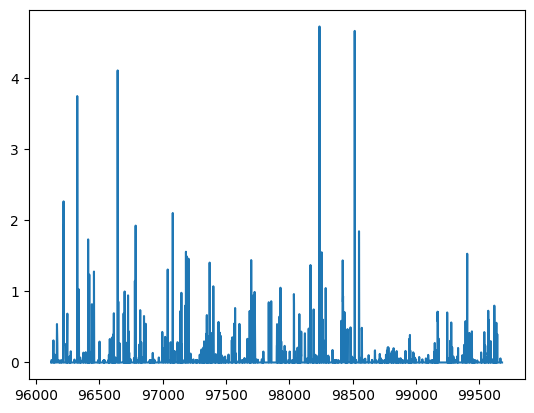

In [85]:
test = pd.read_pickle('../utils/model_files/test_avg_data.pd')
test = test[test.Location.str.contains('Avondale')]
plt.figure()
plt.plot(test.Precip)
plt.show()

In [92]:
import tensorflow as tf

model_fil_path = config['files']['model']
if os.path.exists('{}'.format(model_fil_path)):
  model=tf.keras.models.load_model('{}'.format(model_fil_path), custom_objects={"r2_keras":predictions.r2_keras})
  print('model loaded')
else:
  print('uh oh')

daily_datas = glob.glob('../data/Weather/*daily.pd')

for data_fil in daily_datas:
  data = pd.read_pickle(data_fil)
  #data.Precip = data.Precip*10
  data.rename(columns={'Ref': 'MoLS'}, inplace=True)
    
  loc = str(data.iloc[0,0])
  outfile='../data/Abundance_predictions/'+loc+'_gru_avg_temp_predictions.csv'
  results=predictions.gen_preds(model, data, data_shape, scaler, fit_scaler=False, smooth=False)
  pd.DataFrame(results, columns=['Location','Year','Month','Day','Ref','Neural Network']).to_csv(outfile,index=False)
  
  print('Predictions created for '+loc)

model loaded
69/69 [==============================] - 1s 11ms/step
Predictions created for Arboleda
69/69 [==============================] - 1s 15ms/step
Predictions created for La_Margarita
69/69 [==============================] - 1s 15ms/step
Predictions created for Playa
78/78 [==============================] - 1s 15ms/step
Predictions created for San_Juan
69/69 [==============================] - 1s 15ms/step
Predictions created for Villodas
